## 1.Load Gensim Lib

In [ ]:
!pip install gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.5 MB/s eta 0:00:00


In [ ]:
import gensim

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving labeledTrainData.tsv.zip to labeledTrainData.tsv.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np

### Data: https://www.kaggle.com/c/word2vec-nlp-tutorial/data

In [ ]:
df=pd.read_csv('labeledTrainData.tsv.zip',header=0,delimiter='\t')

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/HGN/NLP By HGN/NLP for SRM /HGN/unit2/labeledTrainData.tsv.zip',header=0,delimiter='\t')

In [ ]:
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [ ]:
df.shape

(25000, 3)

In [ ]:
df.loc[0,"review"]

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [ ]:
import re, string

def clean_str(string):
  try:
    string = re.sub(r'^https?:\/\/<>.*[\r\n]*', '', string, flags=re.MULTILINE)
    string = re.sub(r"[^A-Za-z]", " ", string)
    words = string.strip().lower().split()
    words = [w for w in words if len(w)>=1]
    return " ".join(words)
  except:
    return " "

Removing URLs (though the regex pattern is incorrect).
Removing non-alphabetic characters.
Converting to lowercase.
Splitting words and removing empty entries.








In [ ]:
df['clean_review'] = df['review'].apply(clean_str)
df.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,with all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",the classic war of the worlds by timothy hines...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,the film starts with a manager nicholas bell g...
3,3630_4,0,It must be assumed that those who praised this...,it must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy and wondrously unpretentious s...


### convert review to word list

In [ ]:
documents = []

for doc in df['clean_review']:
  documents.append(doc.split(' '))

In [ ]:
print(len(documents))

25000


In [ ]:
print(documents[0])

['with', 'all', 'this', 'stuff', 'going', 'down', 'at', 'the', 'moment', 'with', 'mj', 'i', 've', 'started', 'listening', 'to', 'his', 'music', 'watching', 'the', 'odd', 'documentary', 'here', 'and', 'there', 'watched', 'the', 'wiz', 'and', 'watched', 'moonwalker', 'again', 'maybe', 'i', 'just', 'want', 'to', 'get', 'a', 'certain', 'insight', 'into', 'this', 'guy', 'who', 'i', 'thought', 'was', 'really', 'cool', 'in', 'the', 'eighties', 'just', 'to', 'maybe', 'make', 'up', 'my', 'mind', 'whether', 'he', 'is', 'guilty', 'or', 'innocent', 'moonwalker', 'is', 'part', 'biography', 'part', 'feature', 'film', 'which', 'i', 'remember', 'going', 'to', 'see', 'at', 'the', 'cinema', 'when', 'it', 'was', 'originally', 'released', 'some', 'of', 'it', 'has', 'subtle', 'messages', 'about', 'mj', 's', 'feeling', 'towards', 'the', 'press', 'and', 'also', 'the', 'obvious', 'message', 'of', 'drugs', 'are', 'bad', 'm', 'kay', 'br', 'br', 'visually', 'impressive', 'but', 'of', 'course', 'this', 'is', 'all

In [ ]:
model=gensim.models.Word2Vec(documents,# List of tokenized sentences
                             min_count=10,# Ignore words appearing less than 10 times
                             workers=4,# Number of CPU cores for training
                             vector_size=50,# Dimension of word embeddings
                             window=5,# Context window size
                             epochs=10)# Number of training iterations

### Exploring the model

In [ ]:
model.wv.vectors.shape

(19874, 50)

In [ ]:
model.wv.key_to_index

{'the': 0,
 'and': 1,
 'a': 2,
 'of': 3,
 'to': 4,
 'is': 5,
 'br': 6,
 'it': 7,
 'in': 8,
 'i': 9,
 'this': 10,
 'that': 11,
 's': 12,
 'was': 13,
 'as': 14,
 'for': 15,
 'with': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 't': 20,
 'you': 21,
 'on': 22,
 'not': 23,
 'he': 24,
 'are': 25,
 'his': 26,
 'have': 27,
 'be': 28,
 'one': 29,
 'all': 30,
 'at': 31,
 'they': 32,
 'by': 33,
 'an': 34,
 'who': 35,
 'so': 36,
 'from': 37,
 'like': 38,
 'there': 39,
 'her': 40,
 'or': 41,
 'just': 42,
 'about': 43,
 'out': 44,
 'if': 45,
 'has': 46,
 'what': 47,
 'some': 48,
 'good': 49,
 'can': 50,
 'more': 51,
 'she': 52,
 'when': 53,
 'very': 54,
 'up': 55,
 'time': 56,
 'no': 57,
 'even': 58,
 'my': 59,
 'would': 60,
 'which': 61,
 'story': 62,
 'only': 63,
 'really': 64,
 'see': 65,
 'their': 66,
 'had': 67,
 'we': 68,
 'were': 69,
 'me': 70,
 'well': 71,
 'than': 72,
 'much': 73,
 'get': 74,
 'bad': 75,
 'been': 76,
 'people': 77,
 'will': 78,
 'do': 79,
 'other': 80,
 'also': 81,
 'into': 

In [ ]:
model.wv['great']

array([-2.335801  , -0.8147216 ,  2.084361  , -0.6272197 , -1.9591157 ,
        0.9741833 , -0.76298976, -2.919219  , -0.8463557 ,  0.89295083,
        1.9193441 ,  2.1316738 , -3.6105385 ,  0.04285436,  2.1419303 ,
       -3.1689365 , -3.0605953 , -2.143732  , -1.2771729 ,  1.7183014 ,
        0.6485637 , -1.0836109 ,  1.4951669 ,  2.7967744 , -2.8739257 ,
       -0.95729256,  4.604066  , -0.5443492 ,  2.2975132 ,  0.6553806 ,
        2.147705  , -2.7870517 , -2.8355956 ,  1.3089882 ,  0.43050936,
        0.34007907,  0.12893471,  1.5366719 ,  1.235451  ,  0.39017385,
        0.6280683 , -0.83499074,  0.7542379 , -1.8787259 , -0.0853483 ,
       -0.26950416, -0.94464177, -1.9900252 , -0.98945093, -0.66318226],
      dtype=float32)

In [ ]:
model.wv.most_similar('great',topn=15)

[('wonderful', 0.8580797910690308),
 ('fantastic', 0.8302344083786011),
 ('good', 0.8277730345726013),
 ('fine', 0.8084990382194519),
 ('brilliant', 0.7675987482070923),
 ('terrific', 0.7493586540222168),
 ('amazing', 0.7385475635528564),
 ('nice', 0.7375643253326416),
 ('superb', 0.723907470703125),
 ('awesome', 0.703083872795105),
 ('excellent', 0.7016785144805908),
 ('perfect', 0.6992285251617432),
 ('decent', 0.6815754771232605),
 ('outstanding', 0.6696891784667969),
 ('marvelous', 0.6684519052505493)]

In [ ]:
model.wv.most_similar('man',topn=15)

[('woman', 0.7392800450325012),
 ('boy', 0.7372266054153442),
 ('guy', 0.7307684421539307),
 ('person', 0.7176883220672607),
 ('doctor', 0.7019268870353699),
 ('soldier', 0.6946542263031006),
 ('cop', 0.6519032120704651),
 ('journalist', 0.6342079639434814),
 ('lady', 0.6339237689971924),
 ('scientist', 0.6320379376411438),
 ('priest', 0.628095805644989),
 ('girl', 0.6253889203071594),
 ('murderer', 0.5942698121070862),
 ('farmer', 0.5925158262252808),
 ('surgeon', 0.5762897729873657)]

In [ ]:
model.wv.doesnt_match(['man','woman','child','kitchen'])

'kitchen'

In [ ]:
model.save('word2vec_movi50.model')

In [ ]:
mymodel=gensim.models.Word2Vec.load('word2vec_movi50.model')

In [ ]:
mymodel.wv.doesnt_match(['man','woman','child','kitchen'])

'kitchen'

In [ ]:
model.wv.most_similar(positive=['king','man'],negative=['queen'])

[('person', 0.500312089920044),
 ('book', 0.4976942837238312),
 ('game', 0.49400657415390015),
 ('guy', 0.4885537922382355),
 ('stephen', 0.4614584147930145),
 ('lion', 0.4465475082397461),
 ('killer', 0.445639967918396),
 ('himself', 0.42432549595832825),
 ('filmmaker', 0.42340460419654846),
 ('writer', 0.4179590940475464)]

## FastText

In [ ]:
from gensim.models import FastText

In [ ]:
# Sample tokenized sentences
documents = [
    ["deep", "learning", "is", "amazing"],
    ["fasttext", "handles", "out", "of", "vocabulary", "words"],
    ["word", "embeddings", "are", "powerful"],
    ["natural", "language", "processing", "rocks"]
]

In [ ]:
# Train FastText model
model = FastText(
    sentences=documents,
    vector_size=50,  # Embedding size (dimensions)
    window=3,        # Context window size
    min_count=1,     # Minimum word frequency to be included in vocabulary
    workers=4,       # Number of CPU threads
    sg=1,            # 1 for Skip-gram, 0 for CBOW
    epochs=10        # Number of training epochs
)

In [ ]:
model.wv.most_similar('great',topn=15)

[('word', 0.20039142668247223),
 ('amazing', 0.18875181674957275),
 ('language', 0.15233109891414642),
 ('powerful', 0.14609329402446747),
 ('embeddings', 0.12843447923660278),
 ('are', 0.11478926241397858),
 ('words', 0.1071641817688942),
 ('natural', 0.10469134151935577),
 ('rocks', 0.1004721075296402),
 ('handles', 0.05730597302317619),
 ('is', 0.05484459176659584),
 ('deep', 0.04649883508682251),
 ('of', 0.04478474333882332),
 ('processing', 0.03606171905994415),
 ('learning', 0.03405589982867241)]

In [ ]:
# Save and load the model
model.save("fasttext.model")
model = FastText.load("fasttext.model")

In [ ]:
# Check vector for a word
print(model.wv["learning"])

[-1.7226944e-03  6.3408993e-04  5.1556708e-05 -1.3025103e-03
 -1.0037953e-03  1.7511551e-03  2.9519661e-03 -1.1062500e-03
 -4.0238537e-03  1.8702484e-03  5.3440104e-04 -1.6093299e-03
  7.3879282e-04  1.5473260e-03  1.8584934e-03 -1.2040877e-03
  1.1299087e-03 -9.7654905e-04 -9.0834073e-04  3.3484113e-03
  1.4255138e-03 -2.8814000e-04 -2.5893438e-03  1.8892097e-03
  2.0255006e-03 -2.1598325e-03 -2.6734257e-03  1.9390668e-03
 -1.0982543e-03  4.2952262e-03  3.6384033e-03  2.4059287e-03
 -2.0475185e-03  1.8139844e-03 -8.6586317e-04 -8.8246394e-04
 -4.1488696e-05  1.5133332e-03  4.2930283e-03  4.1455175e-03
  2.8349464e-03  4.9351086e-04  3.4115526e-03  1.7383702e-04
 -1.6052790e-03 -1.1396146e-03 -3.7334571e-03 -3.7978594e-03
 -2.8156845e-03  6.3705683e-04]


## Word Cloud

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
text = " ".join(df["clean_review"].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",  # Change color theme if needed
    max_words=50,       # Limit words for better visualization
    stopwords=set(stopwords.words("english"))  # Exclude common English stopwords
    ).generate(text)

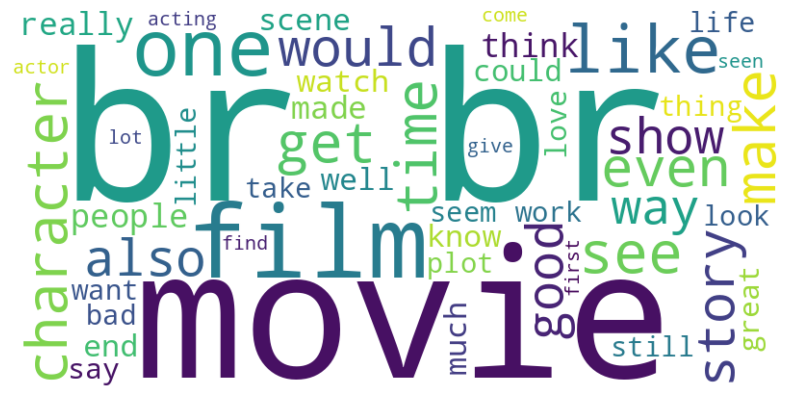

In [ ]:
# Display the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.show()